In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [26]:
df = pd.read_csv("/Users/jennaqasqas/python_decal_sp26/course_assignments/homework9/solar_system.csv")

In [27]:
print(df)

                      Attribute Mercury    Venus  Earth   Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97  0.073  0.642   
1                 Diameter (km)    4879    12104  12756   3475   6792   
2              Density (kg/m^3)    5429     5243   5514   3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8    1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2    2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9  655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0  708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6  0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1  0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1  0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2   27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8    1.0   24.1   
12    Orbital Inclination (deg)     7.0      3.4   

In [28]:
print("shape of dataset:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

shape of dataset: (20, 11)
number of rows: 20
number of columns: 11


In [29]:
print("\nfirst five rows:")

print(df.head())


first five rows:
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  


In [30]:
print("\nlast five rows:")

print(df.tail())


last five rows:
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring System?      No    No    No   No    No      Yes      Yes   
19   Global Magnetic Field?     Yes    No   Yes   No    No      Yes      Yes   

     Uranus  Neptune    Pluto  
15     -195     -200     -225  
16  Unknown  Unknown  0.00001  
17       28       16        5  
18      Yes      Yes       No  
19      Yes      Yes  Unknown  


In [31]:
df = df.set_index("Attribute")
print("\ncolumn names:")
print(df.columns)

print("\nrow names (index):")
print(df.index)


column names:
Index(['Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn',
       'Uranus', 'Neptune', 'Pluto'],
      dtype='str')

row names (index):
Index(['Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
      dtype='str', name='Attribute')


In [32]:
print(df)

                            Mercury    Venus  Earth   Moon   Mars  Jupiter  \
Attribute                                                                    
Mass (10^24kg)                0.330     4.87   5.97  0.073  0.642     1898   
Diameter (km)                  4879    12104  12756   3475   6792   142984   
Density (kg/m^3)               5429     5243   5514   3340   3934     1326   
Gravity (m/s^2)                 3.7      8.9    9.8    1.6    3.7     23.1   
Escape Velocity (km/s)          4.3     10.4   11.2    2.4    5.0     59.5   
Rotation Period (hours)      1407.6  -5832.5   23.9  655.7   24.6      9.9   
Length of Day (hours)        4222.6   2802.0   24.0  708.7   24.7      9.9   
Distance from Sun (10^6 km)    57.9    108.2  149.6  0.384  228.0    778.5   
Perihelion (10^6 km)           46.0    107.5  147.1  0.363  206.7    740.6   
Aphelion (10^6 km)             69.8    108.9  152.1  0.406  249.3    816.4   
Orbital Period (days)          88.0    224.7  365.2   27.3  687.

In [33]:
orbital_period = df.loc["Orbital Period (days)"].astype(float)
perihelion = df.loc["Perihelion (10^6 km)"].astype(float)
aphelion = df.loc["Aphelion (10^6 km)"].astype(float)

In [34]:
semi_major_axis = (perihelion + aphelion) / 2

perihelion: the point in an orbit where the object is closest to the sun.

aphelion: the point in an orbit where the object is furthest from the sun.

semi-major axis: half of the longest diameter of the orbit

In [35]:
semi_major_axis_row = pd.Series(semi_major_axis, name="Semi-major axis (AU)")
df = pd.concat([df, semi_major_axis_row.to_frame().T])
print(df)

                            Mercury    Venus  Earth    Moon   Mars  Jupiter  \
Mass (10^24kg)                0.330     4.87   5.97   0.073  0.642     1898   
Diameter (km)                  4879    12104  12756    3475   6792   142984   
Density (kg/m^3)               5429     5243   5514    3340   3934     1326   
Gravity (m/s^2)                 3.7      8.9    9.8     1.6    3.7     23.1   
Escape Velocity (km/s)          4.3     10.4   11.2     2.4    5.0     59.5   
Rotation Period (hours)      1407.6  -5832.5   23.9   655.7   24.6      9.9   
Length of Day (hours)        4222.6   2802.0   24.0   708.7   24.7      9.9   
Distance from Sun (10^6 km)    57.9    108.2  149.6   0.384  228.0    778.5   
Perihelion (10^6 km)           46.0    107.5  147.1   0.363  206.7    740.6   
Aphelion (10^6 km)             69.8    108.9  152.1   0.406  249.3    816.4   
Orbital Period (days)          88.0    224.7  365.2    27.3  687.0     4331   
Orbital Velocity (km/s)        47.4     35.0   29.8 

In [36]:
print("\nshape:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])


shape: (21, 10)
number of rows: 21
number of columns: 10


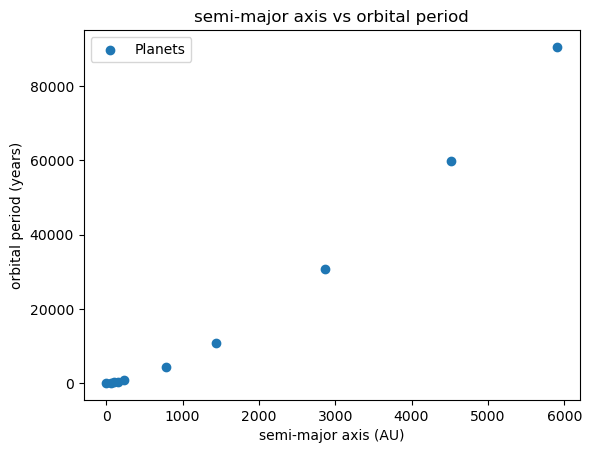

In [40]:
plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.xlabel("semi-major axis (AU)")
plt.ylabel("orbital period (years)")
plt.title("semi-major axis vs orbital period")
plt.legend()
plt.show()

In [41]:
def keplers_third_law(a, m):
    return m * a**1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=[1])
m_fit = popt[0]

In [42]:
print(f"fit: T = {m_fit:.2f} * a^(1.5)")


fit: T = 0.20 * a^(1.5)


In [44]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof
print(f"reduced chi-squared: {chi2_reduced:.2f}")


reduced chi-squared: 41276.71


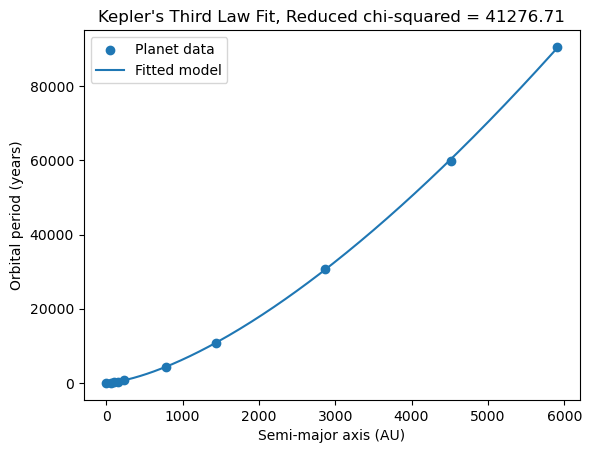

In [45]:
a_fit = np.linspace(semi_major_axis.min(), semi_major_axis.max(), 200)
plt.scatter(semi_major_axis, orbital_period, label="Planet data")
plt.plot(a_fit, keplers_third_law(a_fit, m_fit), label="Fitted model")
plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital period (years)")
plt.title(f"Kepler's Third Law Fit, Reduced chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [46]:
df.to_csv("kepler.csv")